# 04 — Detuning Sweep

Run VQE across a range of detunings (warm-starting each point from the previous optimum), store the results, and produce the final comparison figures against the exact model.

In [1]:
import sys
import os
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.hamiltonian import bragg_hamiltonian
from src.encoding import padded_bragg_hamiltonian, pauli_decompose
from src.exact_solver import ground_state, ground_state_populations
from src.vqe_solver import make_ansatz, run_vqe

In [2]:
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.facecolor": "#0b1020",
    "axes.facecolor": "#0b1020",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": "#e2e8f0",
    "xtick.color": "#cbd5e1",
    "ytick.color": "#cbd5e1",
    "text.color": "#e2e8f0",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.5,
    "grid.color": "#334155",
    "grid.alpha": 0.35,
    "axes.grid": True,
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

## Run the sweep

In [3]:
delta_values_vqe = np.linspace(-8, 8, 33)
omega, penalty = 0.5, 13.0
previous_optimal_parameters = None

results = {
    "delta": [], "exact_energy": [], "vqe_energy": [], "energy_error": [],
    "fidelity": [], "p_minus": [], "p_zero": [], "p_plus": [], "leakage": [],
}

for delta in delta_values_vqe:
    H_matrix = padded_bragg_hamiltonian(delta, omega, penalty)
    H_pauli = pauli_decompose(H_matrix)

    if previous_optimal_parameters is None:
        initial_point = 2 * np.pi * np.random.random(4)
    else:
        initial_point = previous_optimal_parameters

    result, vqe_state = run_vqe(H_pauli, initial_point=initial_point)
    vqe_energy = np.real(result.eigenvalue)
    previous_optimal_parameters = np.asarray(result.optimal_point, dtype=float)

    exact_energy, exact_state_3d = ground_state(delta, omega)
    exact_state_4d = np.array([*exact_state_3d, 0.0], dtype=complex)

    fidelity = abs(np.vdot(exact_state_4d, vqe_state)) ** 2
    populations = np.abs(vqe_state) ** 2

    results["delta"].append(delta)
    results["exact_energy"].append(exact_energy)
    results["vqe_energy"].append(vqe_energy)
    results["energy_error"].append(abs(vqe_energy - exact_energy))
    results["fidelity"].append(fidelity)
    results["p_minus"].append(populations[0])
    results["p_zero"].append(populations[1])
    results["p_plus"].append(populations[2])
    results["leakage"].append(populations[3])

os.makedirs("../results", exist_ok=True)
sweep_df = pd.DataFrame(results)
sweep_df.to_csv("../results/vqe_detuning_sweep.csv", index=False)
sweep_df.head()

,delta,exact_energy,vqe_energy,energy_error,fidelity,p_minus,p_zero,p_plus,leakage
0,-8.0,-4.061786,-4.061786,1.887940e-08,1.0,0.984962,0.015024,0.000015,5.779991e-13
1,-7.5,-3.570348,-3.570348,9.656873e-08,1.0,0.980604,0.019375,0.000021,1.943329e-09
2,-7.0,-3.081597,-3.081597,3.225187e-08,1.0,0.974052,0.025915,0.000033,6.856659e-11
3,-6.5,-2.596979,-2.596978,1.938653e-07,1.0,0.963793,0.036154,0.000053,2.054494e-11
4,-6.0,-2.119132,-2.119132,7.910411e-08,1.0,0.946263,0.053645,0.000092,9.150658e-10


## Figure 2 — Exact and VQE ground-state energies vs detuning

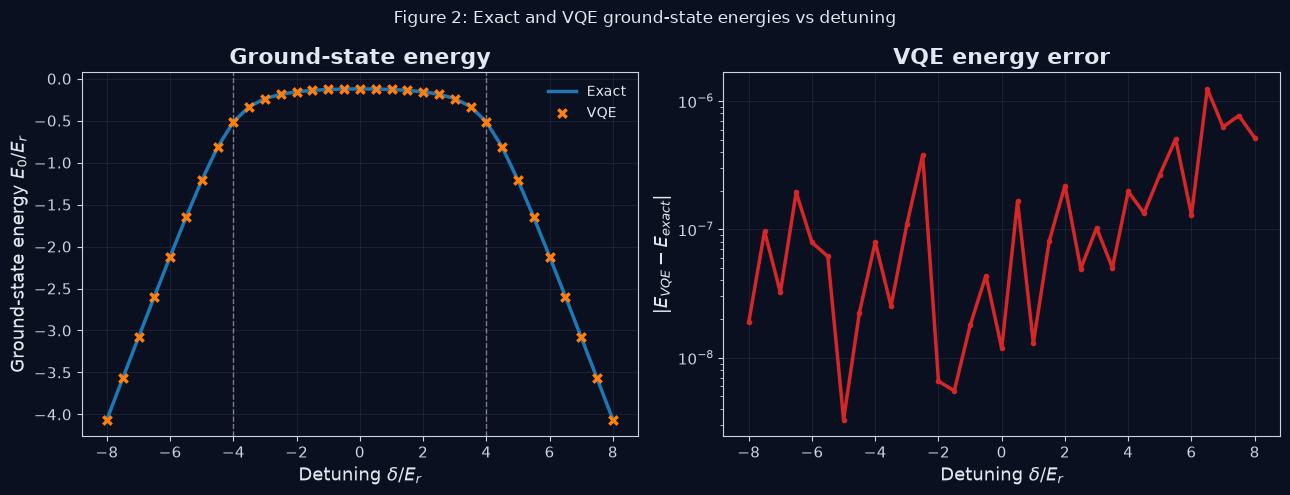

In [4]:
os.makedirs("../figures", exist_ok=True)

fig, (ax_energy, ax_error) = plt.subplots(1, 2, figsize=(13, 5))

ax_energy.plot(sweep_df["delta"], sweep_df["exact_energy"], label="Exact", color="tab:blue")
ax_energy.scatter(sweep_df["delta"], sweep_df["vqe_energy"], label="VQE", color="tab:orange", marker="x", zorder=3)
ax_energy.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax_energy.axvline(4, color="grey", linestyle="--", linewidth=1)
ax_energy.set_xlabel(r"Detuning $\delta / E_r$")
ax_energy.set_ylabel(r"Ground-state energy $E_0 / E_r$")
ax_energy.set_title("Ground-state energy")
ax_energy.legend()

ax_error.semilogy(sweep_df["delta"], sweep_df["energy_error"], color="tab:red", marker="o", markersize=3)
ax_error.set_xlabel(r"Detuning $\delta / E_r$")
ax_error.set_ylabel(r"$|E_{VQE} - E_{exact}|$")
ax_error.set_title("VQE energy error")

fig.suptitle("Figure 2: Exact and VQE ground-state energies vs detuning")
fig.tight_layout()
fig.savefig("../figures/fig2_exact_vqe_energy.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — Exact and VQE momentum populations vs detuning

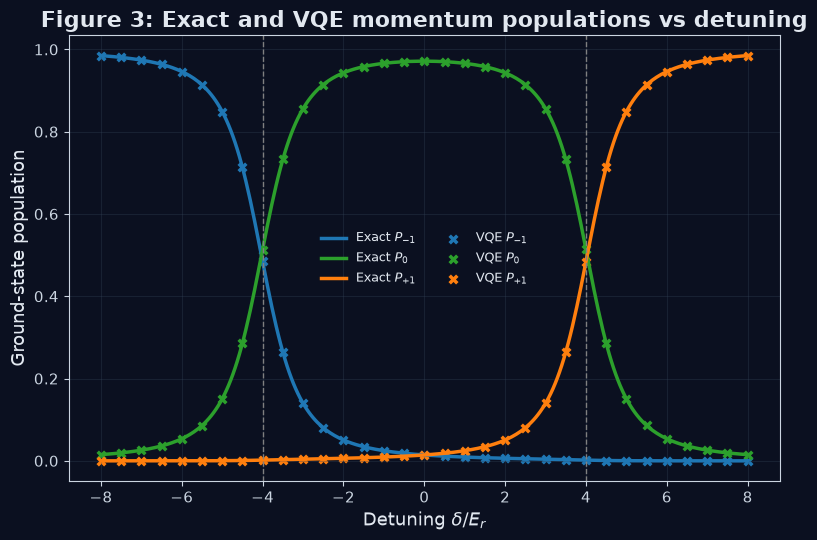

Max leakage into |11>: 2.1727713333350016e-09


In [5]:
delta_values_exact = np.linspace(-8, 8, 300)
population_data = ground_state_populations(delta_values_exact, omega=omega)

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {"minus": "tab:blue", "zero": "tab:green", "plus": "tab:orange"}

ax.plot(delta_values_exact, population_data[:, 0], color=colors["minus"], label=r"Exact $P_{-1}$")
ax.plot(delta_values_exact, population_data[:, 1], color=colors["zero"], label=r"Exact $P_0$")
ax.plot(delta_values_exact, population_data[:, 2], color=colors["plus"], label=r"Exact $P_{+1}$")

ax.scatter(sweep_df["delta"], sweep_df["p_minus"], color=colors["minus"], marker="x", s=30, label=r"VQE $P_{-1}$")
ax.scatter(sweep_df["delta"], sweep_df["p_zero"], color=colors["zero"], marker="x", s=30, label=r"VQE $P_0$")
ax.scatter(sweep_df["delta"], sweep_df["p_plus"], color=colors["plus"], marker="x", s=30, label=r"VQE $P_{+1}$")

ax.axvline(-4, color="grey", linestyle="--", linewidth=1)
ax.axvline(4, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel(r"Detuning $\delta / E_r$")
ax.set_ylabel("Ground-state population")
ax.set_title("Figure 3: Exact and VQE momentum populations vs detuning")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig("../figures/fig3_exact_vqe_populations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Max leakage into |11>:", sweep_df["leakage"].max())

## Figure 5 — VQE ground-state momentum-space probability density at $\delta = -4, 0, 4$

<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
C:\Users\aarya\AppData\Local\Temp\ipykernel_27020\3860955381.py:22: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel("Momentum order $n$ (units of $2\hbar k_L$)")


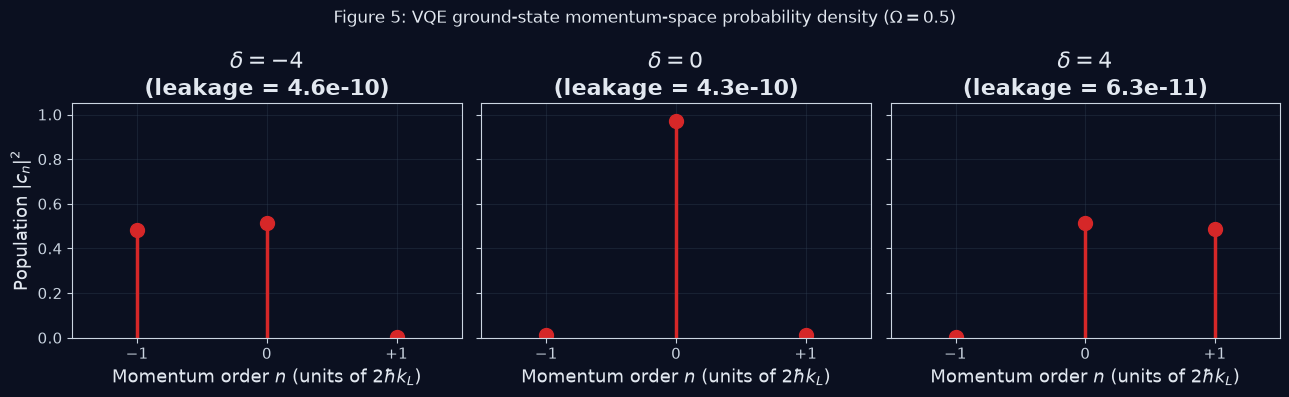

In [6]:
wavefunction_deltas = [-4.0, 0.0, 4.0]
momentum_orders = np.array([-1, 0, 1])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
rng_wf = np.random.default_rng(0)

for ax, delta_wf in zip(axes, wavefunction_deltas):
    H_pauli_wf = pauli_decompose(padded_bragg_hamiltonian(delta_wf, omega, penalty))
    initial_point_wf = 2 * np.pi * rng_wf.random(4)
    _, vqe_state_wf = run_vqe(H_pauli_wf, initial_point=initial_point_wf)
    populations_wf = np.abs(vqe_state_wf) ** 2

    markerline, stemlines, baseline = ax.stem(momentum_orders, populations_wf[:3], basefmt=" ")
    plt.setp(markerline, markersize=10, color="tab:red")
    plt.setp(stemlines, linewidth=2.5, color="tab:red")

    ax.set_xticks(momentum_orders)
    ax.set_xticklabels([r"$-1$", r"$0$", r"$+1$"])
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(rf"$\delta = {delta_wf:g}$" + f"\n(leakage = {populations_wf[3]:.1e})")
    ax.set_xlabel("Momentum order $n$ (units of $2\hbar k_L$)")

axes[0].set_ylabel(r"Population $|c_n|^2$")
fig.suptitle(r"Figure 5: VQE ground-state momentum-space probability density ($\Omega = 0.5$)")
fig.tight_layout()
fig.savefig("../figures/fig5_momentum_wavefunctions.png", dpi=150, bbox_inches="tight")
plt.show()

## Energy / fidelity comparison table

In [7]:
sample_deltas = [-8.0, -4.0, -2.0, 0.0, 2.0, 4.0, 8.0]
comparison_table = sweep_df[sweep_df["delta"].isin(sample_deltas)][
    ["delta", "exact_energy", "vqe_energy", "energy_error", "fidelity"]
].reset_index(drop=True)
comparison_table

,delta,exact_energy,vqe_energy,energy_error,fidelity
0,-8.0,-4.061786,-4.061786,1.887940e-08,1.0
1,-4.0,-0.514896,-0.514896,7.952470e-08,1.0
2,-2.0,-0.156534,-0.156534,6.557047e-09,1.0
3,0.0,-0.121320,-0.121320,1.182745e-08,1.0
4,2.0,-0.156534,-0.156534,2.194401e-07,1.0
5,4.0,-0.514896,-0.514895,1.975749e-07,1.0
6,8.0,-4.061786,-4.061786,5.161411e-07,1.0
